In [1]:
import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.ppo import MlpPolicy

# from imitation.algorithms.adversarial.airl import AIRL
from IRL_lib_mod.airl import AIRL
from imitation.data import rollout
from imitation.data.wrappers import RolloutInfoWrapper
from imitation.policies.serialize import load_policy
from imitation.rewards.reward_nets import BasicShapedRewardNet
from imitation.util.networks import RunningNorm
from utils.irl_utils import make_vec_env_robosuite
from utils.demostration_utils import load_dataset_to_trajectories
import os
import h5py
import json
from robosuite.controllers import load_controller_config
from utils.demostration_utils import load_dataset_and_annotations_simutanously
from utils.annotation_utils import read_all_json
from imitation.util import logger as imit_logger
import imitation.scripts.train_adversarial as train_adversarial
import argparse
import robosuite as suite
import torch
from utils.demostration_utils import load_data_to_h5py
from utils.annotation_utils import write_to_json
import time
import matplotlib.pyplot as plt
import numpy as np
import scipy
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

/home/hang/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/hang/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/hang/.local/lib/python3.10/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)


In [2]:


notebook_path = os.getcwd()  # Get current working directory (where the notebook is running)
notebook_path = os.path.abspath(notebook_path)  # Get absolute path of the notebook
#- "experiments"
project_path = notebook_path.split("data analysis")[0]
print(project_path)
dataset_path = os.path.join(project_path, "human-demo/lift/low_dim_v141_lift_ph.hdf5")
# Now, proceed with your h5py file operations
f = h5py.File(dataset_path, 'r')
env_meta = json.loads(f["data"].attrs["env_args"])
make_env_kwargs = dict(
    robots="Panda",             # load a Sawyer robot and a Panda robot
    gripper_types="default",                # use default grippers per robot arm
    controller_configs=env_meta["env_kwargs"]["controller_configs"],   # each arm is controlled using OSC
    has_renderer=True,                      # on-screen rendering
    render_camera="frontview",              # visualize the "frontview" camera
    has_offscreen_renderer=True,           # no off-screen rendering
    control_freq=20,                        # 20 hz control for applied actions
    horizon=300,                            # each episode terminates after 200 steps
    use_object_obs=True,                   # no observations needed
    use_camera_obs=False,
    reward_shaping=True,
)
SEED = 42

env = suite.make(
    "Lift",
    **make_env_kwargs,
)

/home/hang/learning-with-progress


In [3]:
class CustomLoggingPolicy(MlpPolicy):
    def forward(self, obs: torch.Tensor, deterministic: bool = False):
        global print_cnt
        print_cnt += 1

            # Get the action, value, and log probability from the parent class
        actions, values, log_probs = super().forward(obs, deterministic)
        if print_cnt % 2000 == 0:
            print(f"Actions: {actions[-1].detach().cpu().numpy()}")
                        # Convert actions to NumPy for easier processing
            actions_np = actions.detach().cpu().numpy()
            # Update total actions and count of positive last elements

            positive_last = np.sum(actions_np[:, -1] > 0)
            ratio = positive_last / actions_np.shape[0]
            print(f"Positive ratio: {ratio}")

        # Log the actions (you can adjust the logging as needed)


        # Return the outputs as usual
        return actions, values, log_probs

def evaluate_policy_on_env(env, 
                           exp_name,
                           checkpoint,
                           evaluate_times=10, 
                           render=False):
    custom_objects = {
        'policy_class': CustomLoggingPolicy
    }
    reward_net_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    policy = PPO.load(f"{project_path}/checkpoints/{exp_name}/{checkpoint}/gen_policy/model", custom_objects=custom_objects, device = reward_net_device)
    reward_net = torch.load(f"{project_path}/checkpoints/{exp_name}/{checkpoint}/reward_train.pt", map_location=reward_net_device)
    reward_net.eval()
    reward_net.to(reward_net_device)
    reward_net_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    reward_net.to(reward_net_device)
    obs_keys = ["cube_pos", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
    
    env_rewards = []
    correlations = []
    normalized_pearson_correlations = []
    normalized_spearman_correlations = []
    success_cnt = 0
    SEED = 1
    for i in range(evaluate_times):
        obs = env.reset()
        obs = [obs[key] for key in obs_keys]
        obs = np.concatenate(obs)
        past_action = np.zeros(7)
        done = False
        cnt = 0
        rewards= []
        total_disc_rew = []
        frames = []
        while not done:
            
            #action, _states = policy.predict(obs)
            action, _ = policy.predict(obs, deterministic=True)
            cnt += 1
            if render:
                env.render()
                frame = env.render()
                frames.append(frame)
            obs = torch.tensor(obs).float().unsqueeze(0).to(reward_net_device)
            obs = obs.cpu().detach().numpy()
            # print("obs", obs)   
            
            #action, _ = policy.predict(obs, deterministic=True)
            action = action.squeeze()
            #print(action)
            # if cnt > 200:
            #     action[6] = 1
            #action = action.cpu().detach().numpy().squeeze()

            next_obs, reward, next_done, info = env.step(action)
            
            next_obs = [next_obs[key] for key in obs_keys]
            next_obs = np.concatenate(next_obs)
            # # print(next_obs)
            obs = torch.tensor(obs).float().unsqueeze(0).to(reward_net_device)
            obs_tensor = obs.unsqueeze(0).to(reward_net_device).detach()
            action_tensor = torch.tensor(action).float().unsqueeze(0).to(reward_net_device)
            next_obs_tensor = torch.tensor(next_obs).float().unsqueeze(0).to(reward_net_device)
            done = torch.tensor([0]).float().unsqueeze(0).to(reward_net_device)
            # get the reward from the reward network
            disc_rew = reward_net(obs_tensor, action_tensor, next_obs_tensor, done)
            total_disc_rew.append(disc_rew.item())
            rewards.append(reward)
            # print(type(reward))
            # print(type(disc_rew.item()))
            obs = next_obs
            past_action = action
            #print(f"Discriminator Reward: {disc_rew}")
            # if action[6] > 0:
            #     print(f"gripper action: {action[6]}")
            if render:
                env.render()

                #print("******************Success*********************")
            # print("done", next_done)
            # print("info", info)
            #env.render()
            if next_done:
                #print("yessssssss")
                if obs[2] > 0.856:
                    success_cnt += 1
                break
       # video_path = os.path.join(video_dir, f"episode_{i+1}.mp4")
        
        print(f"Total Discriminator Reward: {sum(total_disc_rew)}")
        print(f"Total Reward: {sum(rewards)}")


        
        # Compute correlations
        correlation = scipy.stats.spearmanr(rewards, total_disc_rew)
        # normalized_pearson = scipy.stats.pearsonr(rewards_normalized, total_disc_rew_normalized)
        # normalized_spearman = scipy.stats.spearmanr(rewards_normalized, total_disc_rew_normalized)
        
        #print(f"Correlation (Spearman): {correlation[0]}")
        # print(f"Normalized Pearson Correlation: {normalized_pearson[0]}")
        # print(f"Normalized Spearman Correlation: {normalized_spearman[0]}")
        
        correlations.append(correlation[0])
        # normalized_pearson_correlations.append(normalized_pearson[0])
        # normalized_spearman_correlations.append(normalized_spearman[0])

        env_rewards.append(sum(rewards))

        # imageio.mimwrite(video_path, frames, fps=20, codec='libx264')
        # print(f"Saved video for episode {i+1} at {video_path}")

    print(f"Success Rate: {success_cnt}/{evaluate_times}")
    print(f"Average Reward: {np.mean(env_rewards)}")
    print(f"Average Correlation: {np.mean(correlations)}")
    print(f"reward list: {env_rewards}")
    return success_cnt, env_rewards, correlations, policy, reward_net

In [4]:
# AIRL_success, AIRL_rewards, AIRL_correlations, AIRL_policy, AIRL_reward_net = evaluate_policy_on_env(env, exp_name="DPHIRL_lift_ph_no_shaping",
#                                                                                                       checkpoint="260",
#                                                                         evaluate_times=50, render=False)

# PHIRL_success, PHIRL_rewards, PHIRL_correlations, PHIRL_policy, PHIRL_reward_net = evaluate_policy_on_env(env, exp_name="DPHIRL_lift_ph_portion_shaping", 
#                                                                                                           checkpoint="340",
#                                                                         evaluate_times=50, render=False)

# ---DATA --- SAVE TIME
PHIRL_mh_success, PHIRL_mh_rewards, PHIRL_mh_correlations, PHIRL_mh_policy, PHIRL_mh_reward_net = evaluate_policy_on_env(env, exp_name="DPHIRL_lift_mh_adv_shaping",
                                                                                                            checkpoint="590",
                                                                        evaluate_times=1, render=False)
_, _, _, AIRL_policy, AIRL_reward_net = evaluate_policy_on_env(env, exp_name="DPHIRL_lift_ph_no_shaping",
                                                                                                      checkpoint="260",
                                                                        evaluate_times=1, render=False)
_, _, _, PHIRL_policy, PHIRL_reward_net = evaluate_policy_on_env(env, exp_name="DPHIRL_lift_ph_portion_shaping",
                                                                                                            checkpoint="340",
                                                                        evaluate_times=1, render=False)

AIRL_mh_success, AIRL_mh_rewards, AIRL_mh_correlations, AIRL_mh_policy, AIRL_mh_reward_net = evaluate_policy_on_env(env, exp_name="DPHIRL_lift_mh_cube_pos",
                                                                                                        checkpoint="410",
                                                                        evaluate_times=1, render=False)

                                                                                                                         




                                                                
AIRL_success = 5
PHIRL_success = 32
AIRL_mh_success = 0
PHIRL_mh_success = 4
AIRL_rewards = [
    206.57986295771886, 51.06715103562107, 220.22853034677777, 140.61447930390045, 
    123.9000693238629, 139.72585841921145, 131.72575872063544, 71.70472339435717, 
    184.2159272869943, 44.29771317785023, 134.93940962462042, 133.77986972252785, 
    57.43039021884939, 252.89434582771048, 131.7843152672818, 142.62730305526813, 
    157.35949574404304, 190.39830269112082, 126.37195117566708, 237.99010783307506, 
    64.13545667327783, 56.72534751743516, 247.96473865105375, 250.12326612152424, 
    170.53048756256354, 201.49023584815038, 147.35553032208898, 171.18251780138309, 
    61.239191321993104, 117.29614341152254, 114.26951951732875, 135.16269395538689, 
    108.20527793012174, 130.6920614814562, 218.03674369179976, 123.92263903855796, 
    238.80042208110956, 138.4657210707787, 137.25894428332987, 127.11593794512228, 
    151.40667578536917, 137.71322778023873, 141.4490083032543, 253.31732059405687, 
    74.59349679893094, 123.32263172702622, 133.66064524312804, 136.40477709542307, 
    124.05788313764917, 190.25075425408713
]
PHIRL_rewards = [
    283.1150659545733, 34.786257683205136, 150.37137519674866, 258.3754049095754, 
    19.43184734059682, 280.93430213435937, 182.04712046381258, 62.7067096367632, 
    253.92831845829426, 62.90422540295453, 260.29108966241654, 227.0906232964489, 
    211.8856903960625, 253.0365998296577, 281.4021750947392, 61.305309942768055, 
    184.8567184164695, 255.636211332732, 280.6136162989196, 66.1101669328292, 
    255.3555238615754, 67.15104479875299, 279.0619702301186, 227.02409114296623, 
    26.093144126080087, 221.35969178814136, 246.3629976812703, 268.7158598024736, 
    187.85178151386907, 234.45921292590936, 142.51770235787217, 252.592053686751, 
    66.85015855715481, 220.14182861065345, 260.1177262392964, 242.07729944676123, 
    15.158395832722329, 171.92320419312452, 95.40920492028182, 277.4059152227021, 
    58.53319852045176, 259.45751503852705, 16.90828405405507, 151.58646664813756, 
    278.34703696690644, 277.72604387812646, 253.93873592915426, 253.7999555107038, 
    59.733775341047114, 282.7139941857061
]

AIRL_mh_rewards =[91.92398797125911, 70.40122796635048, 82.59730860584784, 85.55714974557903, 85.31477530215899, 91.249482346094, 93.52404571911784, 
                  79.86604268493058, 84.63300141942796, 54.47331492220435, 84.23811706336336, 93.24484570322713, 88.68354967226448, 91.6209927979795, 
                  92.03617342097701, 91.34480895907595, 81.33936843039537, 88.01752709680974, 84.36121344254637, 83.86226929304634, 69.17345916528242, 
                  58.926683873609356, 88.99154743376239, 93.37343177286468, 92.76452170477133, 86.34723674913333, 85.27939016843082, 86.1651437174969, 
                  72.65297095479438, 75.3992486955049, 62.24084149950697, 92.27642621766296, 62.362499453954605, 85.51311840065057, 79.63332919111126, 
                  86.52298151235175, 91.3290103619154, 89.13367096674043, 85.1099322927023, 89.22086457491153, 83.27695570801356, 86.24513267874957, 
                  84.52701962896093, 91.85982956060317, 90.25032931744879, 79.03655378765583, 82.87247935888296, 88.99350538032232, 83.3696772079629, 
                  95.42870517983589]

PHIRL_mh_rewards = [115.8342124071247, 126.42904457310445, 104.78254025812532, 132.0171117819104, 126.50068687679173, 116.93863610771515, 
                    125.62044806984089, 127.46288805798079, 111.42717099702213, 132.25993859032508, 107.31531167836944, 134.55230556355014,
                      65.96222638036937, 107.5226010151226, 134.18900508952103, 113.19231351358599, 121.89139927497762, 128.93978189124047, 
                      127.55530864262161, 124.54923124774018, 124.0188183909454, 129.37608156061327, 115.01256412587401, 115.6100328328778, 
                      125.31609548248515, 99.26098903774135, 83.20861245448005, 107.24008192522605, 121.72496458262866, 98.15515232642096, 
                      82.53210486640857, 106.65043286931528, 130.19211595744682, 96.38160440356299, 129.92181411449596, 122.35695885052164, 
                      128.08074190410977, 107.38770126807796, 127.00206067508444, 125.89372004161068, 127.13018976074515, 129.29726349639722, 
                      126.87134022570169, 108.36136112733178, 
                    129.41454648277403, 129.56463491354646, 120.98680288010729, 108.46472590797602, 121.38699866557745, 133.058741376971]


/home/hang/.local/lib/python3.10/site-packages/stable_baselines3/common/save_util.py:166: UserWarning: Could not deserialize object clip_range. Consider using `custom_objects` argument to replace this object.
Exception: code expected at most 16 arguments, got 18
  warnings.warn(
/home/hang/.local/lib/python3.10/site-packages/stable_baselines3/common/save_util.py:166: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code expected at most 16 arguments, got 18
  warnings.warn(
/home/hang/.local/lib/python3.10/site-packages/stable_baselines3/common/save_util.py:449: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In 

Total Discriminator Reward: 1770.5776596069336
Total Reward: 98.53190994104753
Success Rate: 0/1
Average Reward: 98.53190994104753
Average Correlation: 0.3507247858309537
reward list: [98.53190994104753]


/home/hang/.local/lib/python3.10/site-packages/stable_baselines3/common/save_util.py:166: UserWarning: Could not deserialize object clip_range. Consider using `custom_objects` argument to replace this object.
Exception: code expected at most 16 arguments, got 18
  warnings.warn(
/home/hang/.local/lib/python3.10/site-packages/stable_baselines3/common/save_util.py:166: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code expected at most 16 arguments, got 18
  warnings.warn(
/home/hang/.local/lib/python3.10/site-packages/stable_baselines3/common/save_util.py:449: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In 

Total Discriminator Reward: 1243.0451345443726
Total Reward: 207.06025846153221
Success Rate: 0/1
Average Reward: 207.06025846153221
Average Correlation: -0.5072699956224086
reward list: [207.06025846153221]
Total Discriminator Reward: 277.9055666923523
Total Reward: 283.1150663849852
Success Rate: 1/1
Average Reward: 283.1150663849852
Average Correlation: -0.19079485549009434
reward list: [283.1150663849852]
Total Discriminator Reward: 2651.4926204681396
Total Reward: 91.92398797125911
Success Rate: 0/1
Average Reward: 91.92398797125911
Average Correlation: -0.40827298081089786
reward list: [91.92398797125911]


TypeError: alpha must be numeric or None, not <class 'list'>

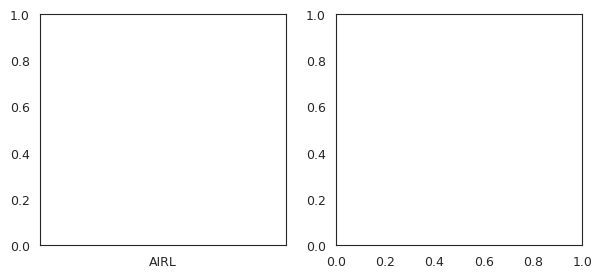

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Update your Matplotlib parameters
plt.rcParams.update({
    "text.usetex": False,        # Do not try to use LaTeX
    "font.family": "serif",      # Use a serif font
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 100            # Increase if you want higher-res
})

# For a clean look, remove the gray background
sns.set_style("white")

# FIGURE SIZE for ~double-column: about 6.5–7 inches wide, ~3–4 inches tall
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# --------------------------
# 1) Left Subplot: Success Rate (Bar Plot)
# --------------------------
methods = ["AIRL", "PHIRL", "AIRL_mh", "PHIRL_mh"]

# Suppose these are the counts of successful episodes out of 50
# Replace with your actual success counts or rates:
AIRL_success = 25
PHIRL_success = 35
AIRL_mh_success = 30
PHIRL_mh_success = 40

success_rates = [
    AIRL_success / 50,
    PHIRL_success / 50,
    AIRL_mh_success / 50,
    PHIRL_mh_success / 50
]


axes[0].set_ylim(0, 1)  # success rate between 0 and 1
axes[0].set_title("Frequency of Success")
axes[0].set_ylabel("Success Rate")

# Annotate bars with fraction (xx/50)
for i, v in enumerate(success_rates):
    fraction_str = f"{int(v*50)}/50"
    axes[0].text(i, v + 0.02, fraction_str, ha='center', color='black')

# Remove top and right spines for a cleaner look
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# --------------------------
# 2) Right Subplot: Reward Distribution (Violin + Dot + Stats)
# --------------------------
# Sample rewards (list or numpy arrays) — replace with your actual data
AIRL_rewards = np.random.normal(loc=5, scale=1, size=50)
PHIRL_rewards = np.random.normal(loc=6, scale=1, size=50)
AIRL_mh_rewards = np.random.normal(loc=7, scale=1, size=50)
PHIRL_mh_rewards = np.random.normal(loc=8, scale=1, size=50)

# Combine into a list-of-lists so Seaborn can interpret them as categories
reward_data = [AIRL_rewards, PHIRL_rewards, AIRL_mh_rewards, PHIRL_mh_rewards]

vio = sns.violinplot(
    data=reward_data,
    inner=None,         # remove internal boxplot
    palette=["C0", "C1", "C0", "C1"],  # match colors if you like
    ax=axes[1],
    width=0.6,
    cut=0               # do not extend beyond data range
)

strip = sns.stripplot(
    data=reward_data,
    color="black",
    size=2.5,
    ax=axes[1]
)

# Compute means and plot them as white markers with black edges
mean_values = [
    np.mean(AIRL_rewards),
    np.mean(PHIRL_rewards),
    np.mean(AIRL_mh_rewards),
    np.mean(PHIRL_mh_rewards)
]
for i, mean_val in enumerate(mean_values):
    axes[1].plot(
        i, mean_val,
        marker='o',
        color='white',
        markersize=6,
        markeredgecolor='black',
        markeredgewidth=0.8
    )

axes[1].set_xticks([0, 1, 2, 3])
axes[1].set_xticklabels(methods)
axes[1].set_title("Reward Distribution")
axes[1].set_ylabel("Reward")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# --------------------------
# 3) (Optional) P-value computations
# --------------------------
# Example: Compare AIRL vs PHIRL (original)
stat_12, p_value_12 = ttest_ind(AIRL_rewards, PHIRL_rewards)
# Example: Compare AIRL_mh vs PHIRL_mh
stat_mh, p_value_mh = ttest_ind(AIRL_mh_rewards, PHIRL_mh_rewards)

p_value_text_12 = f"p (AIRL vs PHIRL) = {p_value_12:.2e}"
p_value_text_mh = f"p (AIRL_mh vs PHIRL_mh) = {p_value_mh:.2e}"

# Position these text annotations near the top
axes[1].text(
    0.5, 0.95, p_value_text_12 + "\n" + p_value_text_mh,
    transform=axes[1].transAxes,
    ha='center',
    va='top',
    fontsize=9
)

fig.tight_layout()
plt.show()


In [6]:
import ptitprince as pt

success_counts = [
    PHIRL_success, 
    AIRL_success,
    PHIRL_mh_success, 
    AIRL_mh_success
]
labels = ["PHIRL_ph", "AIRL_ph", "PHIRL_mh", "AIRL_mh"]

reward_data = [
    PHIRL_rewards, 
    AIRL_rewards, 
    PHIRL_mh_rewards, 
    AIRL_mh_rewards
]

# -- Create the 1x2 figure --
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# ========== LEFT SUBPLOT: Barplot of Success Frequency ==========
bar_colors = sns.color_palette("Set2", n_colors=len(success_counts))
bars = axs[0].bar(range(len(success_counts)), success_counts, color=bar_colors)

# Label each bar with its count
for idx, val in enumerate(success_counts):
    axs[0].text(
        idx, 
        val + 0.5,     # slightly above the top of the bar
        str(val), 
        ha='center', 
        va='bottom',
        fontsize=10
    )

axs[0].set_xticks(range(len(labels)))
axs[0].set_xticklabels(labels, rotation=0)
axs[0].set_ylabel("Number of Successes", fontsize=12)
axs[0].set_title("Success Frequency", fontsize=14)

# ========== RIGHT SUBPLOT: Rewards (Half Violin + Strip + Box) ==========
# You can fine-tune bandwidth (bw), width, etc. to get a pleasing aesthetic
pal = sns.color_palette("Set2", n_colors=len(labels))

# Half-violin plot
pt.half_violinplot(
    x=None,  # we'll supply the data as 'data'
    y=None,
    data=reward_data,
    palette=pal,
    bw=.3,
    cut=0,
    scale="area",
    width=.6,
    inner=None,
    offset = 0.15,         # shift half-violins slightly if needed
    ax=axs[1]
)

# Stripplot (raw points)
sns.stripplot(
    data=reward_data, 
    palette=pal, 
    edgecolor="white",
    size=4, 
    jitter=0.9, 
    zorder=1,
    ax=axs[1]
)

# (Optional) Boxplot overlay
sns.boxplot(
    data=reward_data, 
    width=0.15, 
    showcaps=True, 
    boxprops={'facecolor':'none', "zorder":10}, 
    showfliers=True, 
    whiskerprops={'linewidth':2, "zorder":10},
    saturation=1,
    ax=axs[1]
)

axs[1].set_xticks(range(len(labels)))
axs[1].set_xticklabels(labels, rotation=0)
axs[1].set_ylabel("Reward", fontsize=12)
axs[1].set_title("Reward Distributions", fontsize=14)

plt.tight_layout()
plt.show()

ImportError: cannot import name '_CategoricalScatterPlotter' from 'seaborn.categorical' (/home/hang/.local/lib/python3.10/site-packages/seaborn/categorical.py)

In [49]:
def validate_on_demos( env, policy, reward_net, replay_demo_keys):
    reward_net_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    disc_rewards = { key: [] for key in replay_demo_keys}
    values= { key: [] for key in replay_demo_keys}
    env_rewards = { key: [] for key in replay_demo_keys}
    gripper_close = { key: 0 for key in replay_demo_keys}
    obs_keys = ["cube_pos", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
    for key in replay_demo_keys:
        print("replaying {}: ", key)
        obs = np.array(f["data/{}/obs".format(key)])
        actions = np.array(f["data/{}/actions".format(key)])
        # print(actions)
        dones = np.array(f["data/{}/dones".format(key)])
        # set initial state
        initial_state = f["data/{}/states".format(key)][0]
        
        obs = env.reset()
        env.sim.set_state_from_flattened(initial_state)
        env.sim.forward()
        #env.render()
        reward = 0
        obs,_,_,_ = env.step(np.zeros(7))
        obs = [obs[key] for key in obs_keys]
        obs = np.concatenate(obs)
        past_action = np.zeros(7)
        done = False
        cnt = 0
        for action in actions:
            # print(action)
            next_obs, reward, next_done, info = env.step(action)
            if action[6] == 1 and past_action[6] == -1:
                gripper_close[key] = cnt
            next_obs = [next_obs[key] for key in obs_keys]
            next_obs = np.concatenate(next_obs)
            # print(next_obs)
            
            obs_tensor = torch.tensor(obs).float().unsqueeze(0).to(reward_net_device)
            action_tensor = torch.tensor(action).float().unsqueeze(0).to(reward_net_device)
            next_obs_tensor = torch.tensor(next_obs).float().unsqueeze(0).to(reward_net_device)
            done = torch.tensor([0]).float().unsqueeze(0).to(reward_net_device)
            # get the reward from the reward network
            disc_rew = reward_net(obs_tensor, action_tensor, next_obs_tensor, done)
            rew = reward_net.base(obs_tensor, action_tensor, next_obs_tensor, done)
            value = reward_net.potential(obs_tensor)
            # append reward to rewards
            disc_rewards[key].append(disc_rew.item())
            values[key].append(value.item())
            env_rewards[key].append(rew.item())

            obs = next_obs
            past_action = action
            #print(f"Discriminator Reward: {disc_rew}")
            cnt += 1
            #env.render()
            if next_done:
                break
    return disc_rewards, values, env_rewards, gripper_close




In [50]:
replay_demos = ['demo_0', 'demo_1', 'demo_100', 'demo_101', 'demo_102',] # List of trajectories

AIRL_disc_demo_rewards, AIRL_values, AIRL_env_demo_rewards, AIRL_gripper_close = validate_on_demos(env, AIRL_policy, AIRL_reward_net, replay_demos)
PHIRL_disc_demo_rewards, PHIRL_values, PHIRL_env_demo_rewards, PHIRL_gripper_close = validate_on_demos(env, PHIRL_policy, PHIRL_reward_net, replay_demos)

replaying {}:  demo_0
replaying {}:  demo_1
replaying {}:  demo_100
replaying {}:  demo_101
replaying {}:  demo_102
replaying {}:  demo_0
replaying {}:  demo_1
replaying {}:  demo_100
replaying {}:  demo_101
replaying {}:  demo_102


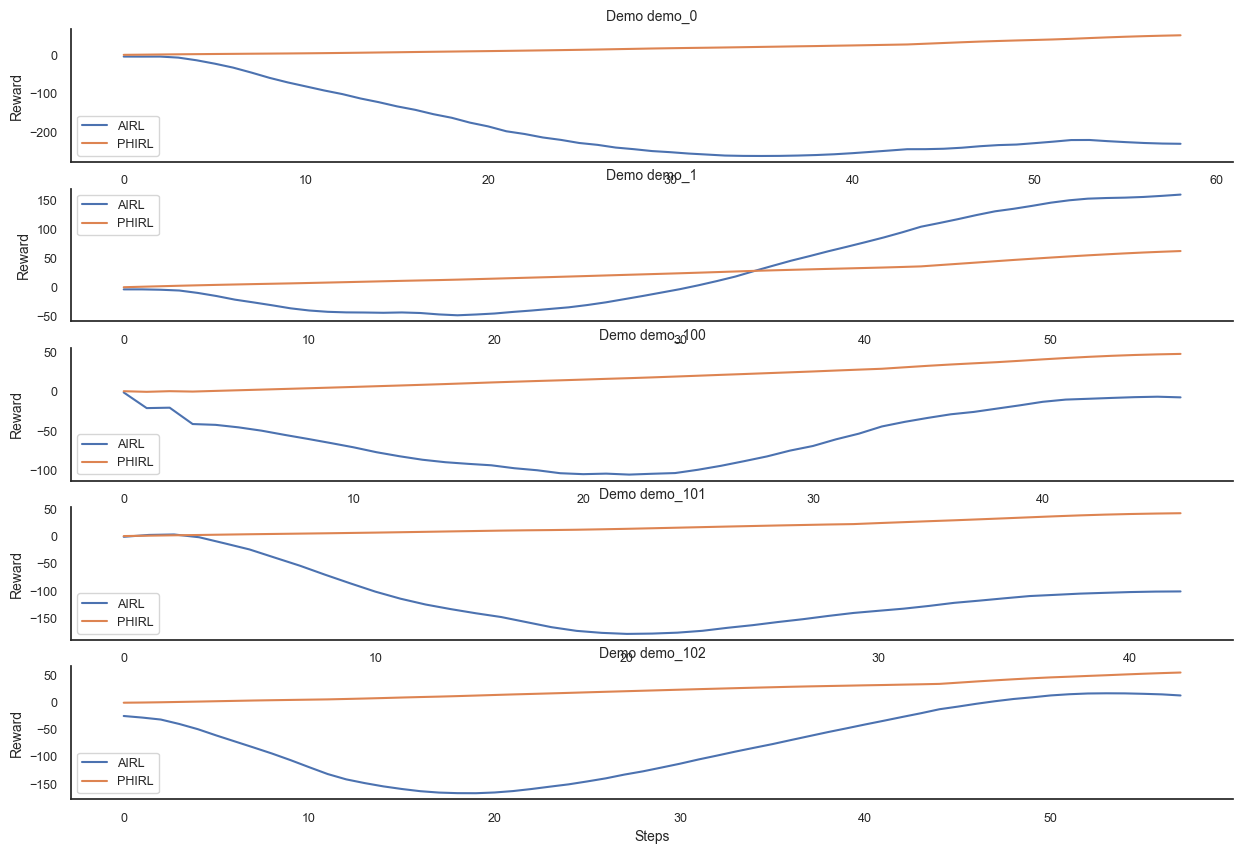

In [51]:
# Plot the reward curves by steps for AIRL_disc_demo_rewards and PHIRL_disc_demo_rewards in the same plot, each demo is one plot. 
# thus 5 plots in total, and each plot has two lines, one for AIRL and one for PHIRL
# x-axis is the steps, y-axis is the reward.
# The title of the plot is the demo name, and the legend is the method name.
# The color of the line is different for different methods.

# FIGURE SIZE for ~double-column: about 6.5–7 inches wide, ~3–4 inches tall
AIRL_disc_demo_accumulate_rewards = {key: np.cumsum(AIRL_env_demo_rewards[key]) for key in AIRL_env_demo_rewards}
PHIRL_disc_demo_accumulate_rewards = {key: np.cumsum(PHIRL_env_demo_rewards[key]) for key in PHIRL_env_demo_rewards}
fig, axes = plt.subplots(5, 1, figsize=(15, 10))
for i, demo in enumerate(replay_demos):
    axes[i].plot(AIRL_disc_demo_accumulate_rewards[demo], label="AIRL", color="C0")
    axes[i].plot(PHIRL_disc_demo_accumulate_rewards[demo], label="PHIRL", color="C1")
    axes[i].set_title(f"Demo {demo}")
    axes[i].set_xlabel("Steps")
    axes[i].set_ylabel("Reward")
    axes[i].legend()
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)


In [72]:
def validate_rewards_with_suboptimal_policy(env,  reward_net, render=False):
    reward_net_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    project_path = notebook_path.split("data analysis")[0]
    custom_objects = {
        'policy_class': CustomLoggingPolicy
    }
    policy = PPO.load(f"{project_path}/checkpoints/DPHIRL_lift_ph_no_shaping/180/gen_policy/model", custom_objects=custom_objects, device = reward_net_device)
    obs_keys = ["cube_pos", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
    evaluate_times = 1
    
    env_rewards = []
    correlations = []
    disc_rewards = []
    gripper_close = []
    gripper_open = []
    success_cnt = 0
    for i in range(evaluate_times):
        obs = env.reset()
        obs = [obs[key] for key in obs_keys]
        obs = np.concatenate(obs)
        past_action = np.zeros(7)
        done = False
        cnt = 0
        rewards= []
        total_disc_rew = []
        frames = []
        while not done:
            
            #action, _states = policy.predict(obs)
            action, _ = policy.predict(obs, deterministic=True)
            cnt += 1
            if render:
                env.render()
                frame = env.render()
                frames.append(frame)
            obs = torch.tensor(obs).float().unsqueeze(0).to(reward_net_device)
            obs = obs.cpu().detach().numpy()
            # print("obs", obs)   
            
            #action, _ = policy.predict(obs, deterministic=True)
            action = action.squeeze()
            #print(action)
            # if cnt > 200:
            #     action[6] = 1
            #action = action.cpu().detach().numpy().squeeze()

            next_obs, reward, next_done, info = env.step(action)
            
            next_obs = [next_obs[key] for key in obs_keys]
            next_obs = np.concatenate(next_obs)
            # # print(next_obs)
            obs = torch.tensor(obs).float().unsqueeze(0).to(reward_net_device)
            obs_tensor = obs.unsqueeze(0).to(reward_net_device).detach()
            action_tensor = torch.tensor(action).float().unsqueeze(0).to(reward_net_device)
            next_obs_tensor = torch.tensor(next_obs).float().unsqueeze(0).to(reward_net_device)
            done = torch.tensor([0]).float().unsqueeze(0).to(reward_net_device)
            # get the reward from the reward network
            disc_rew = reward_net(obs_tensor, action_tensor, next_obs_tensor, done)
            total_disc_rew.append(disc_rew.item())
            rewards.append(reward)
            # print(type(reward))
            # print(type(disc_rew.item()))
            obs = next_obs

            if action[6] > 0 and past_action[6] < 0:
                gripper_close.append(cnt)
            if action[6] < 0 and past_action[6] > 0:
                gripper_open.append(cnt)
            past_action = action
            #print(f"Discriminator Reward: {disc_rew}")
            # if action[6] > 0:
            #     print(f"gripper action: {action[6]}")

            if render:
                env.render()

            if next_done:
                #print("yessssssss")
                if obs[2] > 0.8565:
                    success_cnt += 1
                break
       # video_path = os.path.join(video_dir, f"episode_{i+1}.mp4")
        
        print(f"Total Discriminator Reward: {sum(total_disc_rew)}")
        print(f"Total Reward: {sum(rewards)}")


        
        # Compute correlations
        correlation = scipy.stats.spearmanr(rewards, total_disc_rew)
        correlations.append(correlation[0])


        env_rewards.append(rewards)
        disc_rewards.append(total_disc_rew)


    # print(f"Success Rate: {success_cnt}/{evaluate_times}")
    # print(f"Average Reward: {np.mean(env_rewards)}")
    # print(f"Average Correlation: {np.mean(correlations)}")
    # print(f"reward list: {env_rewards}")
    return success_cnt, env_rewards, disc_rewards, gripper_close, gripper_open

In [73]:
AIRL_test_success, AIRL_test_rewards, AIRL_test_disc_rewards, AIRL_gripper_close, AIRL_gripper_open = validate_rewards_with_suboptimal_policy(env, AIRL_reward_net, render=False)
PHIRL_test_success, PHIRL_test_rewards, PHIRL_test_disc_rewards, PHIRL_gripper_close, PHIRL_gripper_open  = validate_rewards_with_suboptimal_policy(env, PHIRL_reward_net, render=False)


Total Discriminator Reward: 392.37000799179077
Total Reward: 180.40149483504518
Total Discriminator Reward: 355.7651205062866
Total Reward: 180.40149483504518


[38, 120, 200, 291]
[87, 169, 260]


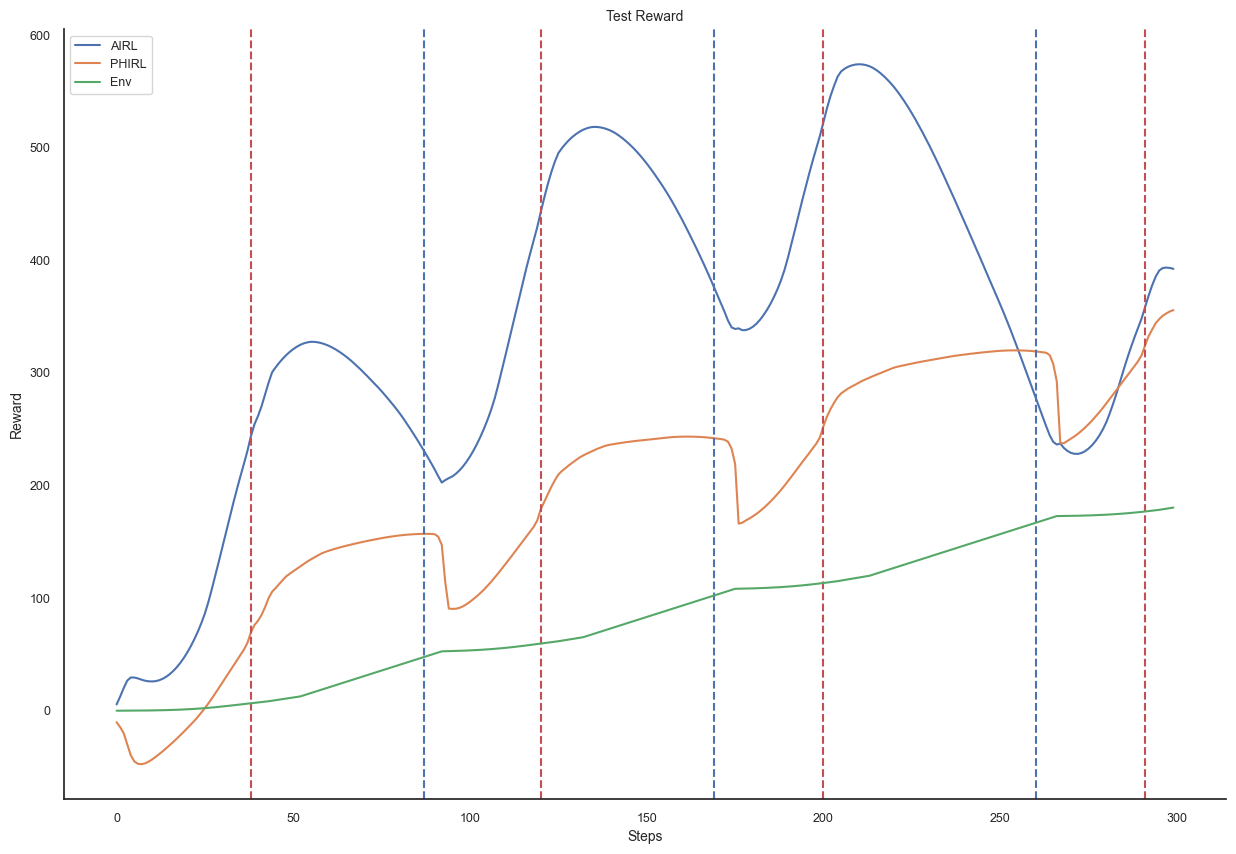

In [75]:
# Plot the reward curves by steps for AIRL_test_disc_rewards and PHIRL_test_disc_rewards in the same plot.
print(AIRL_gripper_close)
print(AIRL_gripper_open)
# FIGURE SIZE for ~double-column: about 6.5–7 inches wide, ~3–4 inches tall
AIRL_test_disc_rewards_accumulate = np.cumsum(AIRL_test_disc_rewards[0])
PHIRL_test_disc_rewards_accumulate = np.cumsum(PHIRL_test_disc_rewards[0])
env_acc_rewards = np.cumsum(AIRL_test_rewards[0])
fig, axes = plt.subplots(1, 1, figsize=(15, 10))
axes.plot(AIRL_test_disc_rewards_accumulate, label="AIRL", color="C0")
axes.plot(PHIRL_test_disc_rewards_accumulate, label="PHIRL", color="C1")

#PLOT OUT THE GRIPPER CLOSE AND OPEN
for i in AIRL_gripper_close:
    axes.axvline(x=i, color='r', linestyle='--')
for i in AIRL_gripper_open:
    axes.axvline(x=i, color='b', linestyle='--')
axes.plot(env_acc_rewards, label="Env", color="C2")
axes.set_title("Test Reward")
axes.set_xlabel("Steps")
axes.set_ylabel("Reward")
axes.legend()
axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)

plt.show()



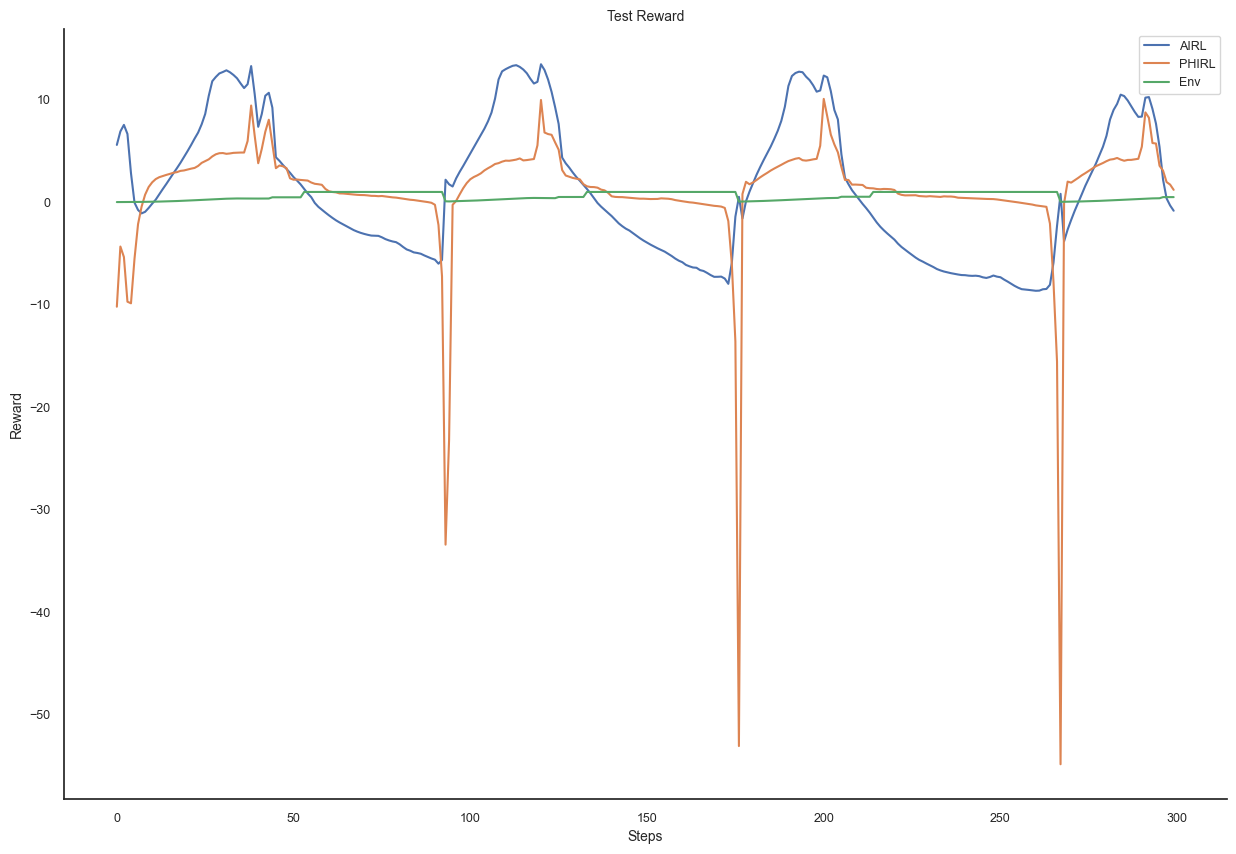

In [60]:
#plot non accumulated rewards
fig, axes = plt.subplots(1, 1, figsize=(15, 10))
axes.plot(AIRL_test_disc_rewards[0], label="AIRL", color="C0")
axes.plot(PHIRL_test_disc_rewards[0], label="PHIRL", color="C1")
axes.plot(AIRL_test_rewards[0], label="Env", color="C2")
axes.set_title("Test Reward")
axes.set_xlabel("Steps")
axes.set_ylabel("Reward")
axes.legend()
axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)

plt.show()